In [ ]:
# ✅ سلول 1: بارگذاری و استخراج دیتا از Google Drive
from google.colab import drive
import zipfile, os

drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/SolarDataset/PVShadingFaults.zip'
extract_path = "/content/PVShadingFaults"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/PVShadingFaults/dt1_solar_and_meteorological_measurement.csv
/content/PVShadingFaults/00_metadata_variable.jpg
/content/PVShadingFaults/dt3_electrical_production_inverter_2.csv
/content/PVShadingFaults/dt2_electrical_production_inverter_1_with_faults.csv


In [ ]:
# ✅ سلول 2: بارگذاری CSV و آماده‌سازی اولیه
import pandas as pd

# بارگذاری دیتای اصلی با برچسب Fault
df = pd.read_csv("/content/PVShadingFaults/dt2_electrical_production_inverter_1_with_faults.csv")

# تبدیل ستون زمان به datetime
df['time'] = pd.to_datetime(df['time'])

# بررسی مقادیر گمشده
missing_values = df.isnull().sum()
print("🔍 مقادیر گمشده در هر ستون:\n", missing_values)

# توزیع کلاس‌های Fault
fault_distribution = df['Fault'].value_counts().sort_index()
print("\n🔢 توزیع کلاس‌های Fault:\n", fault_distribution)

# حذف ردیف‌های دارای مقدار گمشده
df_cleaned = df.dropna().reset_index(drop=True)
print("\n🔁 پس از پاکسازی:\n", df_cleaned.isnull().sum())
print("🔢 شکل جدید داده‌ها:", df_cleaned.shape)


🔍 مقادیر گمشده در هر ستون:
 time      0
Fault     6
Ia       10
Ig       10
Eg       10
Fg       10
Pg       10
Va       10
Vg       10
dtype: int64

🔢 توزیع کلاس‌های Fault:
 Fault
0.0    2904289
1.0       6318
2.1       2148
2.2       2460
2.3       3287
3.1       2717
3.2       6292
4.0      61297
Name: count, dtype: int64

🔁 پس از پاکسازی:
 time     0
Fault    0
Ia       0
Ig       0
Eg       0
Fg       0
Pg       0
Va       0
Vg       0
dtype: int64
🔢 شکل جدید داده‌ها: (2988798, 9)


In [ ]:
# ✅ سلول 3: حذف داده پرت و مقیاس‌بندی
import numpy as np
from sklearn.preprocessing import StandardScaler

features = ['Ia', 'Ig', 'Eg', 'Fg', 'Pg', 'Va', 'Vg']
z_scores = np.abs((df_cleaned[features] - df_cleaned[features].mean()) / df_cleaned[features].std())
outlier_mask = (z_scores > 5).any(axis=1)
df_no_outliers = df_cleaned[~outlier_mask].reset_index(drop=True)

X = df_no_outliers[features]
y = df_no_outliers['Fault']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print("✅ شکل ویژگی‌ها پس از مقیاس‌بندی:", X_scaled_df.shape)

✅ شکل ویژگی‌ها پس از مقیاس‌بندی: (2984023, 7)


In [ ]:
# ✅ سلول 4: ساخت دنباله و تقسیم
sequence_length = 30
X_np = X_scaled_df.values
y_np = y.values

X_sequences, y_labels = [], []
for i in range(len(X_np) - sequence_length):
    X_sequences.append(X_np[i:i + sequence_length])
    y_labels.append(y_np[i + sequence_length])

X_sequences = np.array(X_sequences)
y_labels = np.array(y_labels)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)

train_size = int(0.7 * len(X_sequences))
val_size = int(0.15 * len(X_sequences))
X_train = X_sequences[:train_size]
y_train = y_encoded[:train_size]
X_val = X_sequences[train_size:train_size + val_size]
y_val = y_encoded[train_size:train_size + val_size]
X_test = X_sequences[train_size + val_size:]
y_test = y_encoded[train_size + val_size:]


In [ ]:
# ✅ سلول 5: Undersampling
idx_class_0 = np.where(y_train == 0)[0]
idx_other = np.where(y_train != 0)[0]
idx_class_0_sampled = np.random.choice(idx_class_0, size=10000, replace=False)
idx_balanced = np.concatenate([idx_class_0_sampled, idx_other])
np.random.shuffle(idx_balanced)

X_train_balanced = X_train[idx_balanced]
y_train_balanced = y_train[idx_balanced]

In [ ]:
# ✅ سلول 6: آموزش مدل LSTM
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# تقسیم مجدد مجموعه متعادل‌شده برای آموزش و اعتبارسنجی
X_train_final, X_val_balanced, y_train_final, y_val_balanced = train_test_split(
    X_train_balanced, y_train_balanced,
    test_size=0.2,
    stratify=y_train_balanced,
    random_state=42
)

# EarlyStopping برای جلوگیری از overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# تعریف مدل
model = Sequential([
    LSTM(64, input_shape=(30, 7), return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(8, activation='softmax')  # 8 کلاس
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# آموزش مدل
model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val_balanced, y_val_balanced),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=2
)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
1133/1133 - 33s - 29ms/step - accuracy: 0.8291 - loss: 0.5253 - val_accuracy: 0.8994 - val_loss: 0.2892
Epoch 2/15
1133/1133 - 35s - 31ms/step - accuracy: 0.9082 - loss: 0.2655 - val_accuracy: 0.9250 - val_loss: 0.1988
Epoch 3/15
1133/1133 - 29s - 25ms/step - accuracy: 0.9304 - loss: 0.2052 - val_accuracy: 0.9328 - val_loss: 0.1824
Epoch 4/15
1133/1133 - 37s - 33ms/step - accuracy: 0.9465 - loss: 0.1625 - val_accuracy: 0.9558 - val_loss: 0.1300
Epoch 5/15
1133/1133 - 27s - 24ms/step - accuracy: 0.9536 - loss: 0.1421 - val_accuracy: 0.9690 - val_loss: 0.0945
Epoch 6/15
1133/1133 - 38s - 34ms/step - accuracy: 0.9595 - loss: 0.1248 - val_accuracy: 0.9635 - val_loss: 0.1050
Epoch 7/15
1133/1133 - 42s - 37ms/step - accuracy: 0.9646 - loss: 0.1102 - val_accuracy: 0.9662 - val_loss: 0.0969
Epoch 8/15
1133/1133 - 43s - 38ms/step - accuracy: 0.9683 - loss: 0.0994 - val_accuracy: 0.9658 - val_loss: 0.1071


567/567 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
📊 گزارش طبقه‌بندی روی Validation متعادل:

              precision    recall  f1-score   support

     Class 0       0.97      0.87      0.92      2000
     Class 1       0.99      0.98      0.98       485
     Class 2       0.94      0.78      0.85       430
     Class 3       0.98      0.99      0.98       492
     Class 4       0.96      0.99      0.98       658
     Class 5       0.94      0.93      0.93       543
     Class 6       0.94      0.98      0.96      1258
     Class 7       0.97      0.99      0.98     12254

    accuracy                           0.97     18120
   macro avg       0.96      0.94      0.95     18120
weighted avg       0.97      0.97      0.97     18120



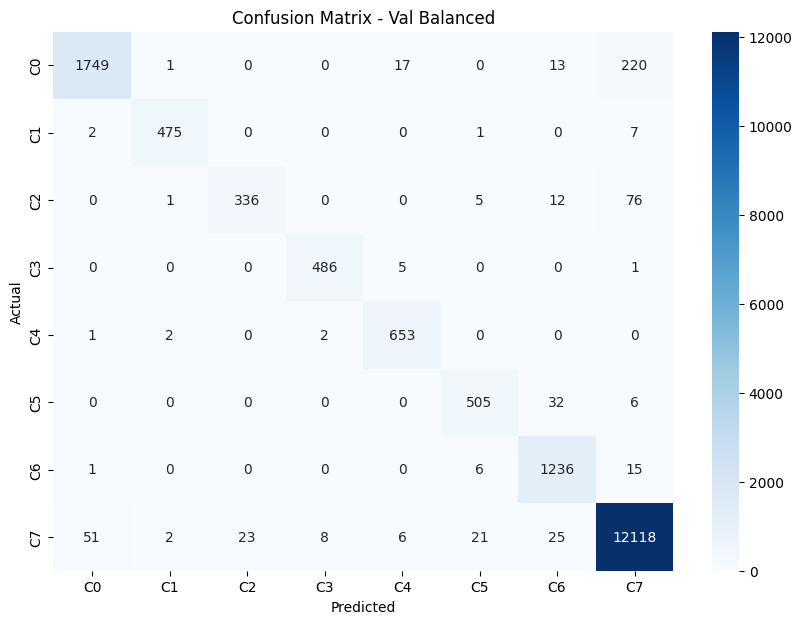

In [ ]:
# ✅ سلول 7: ارزیابی مدل
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_val_pred = model.predict(X_val_balanced)
y_val_classes = np.argmax(y_val_pred, axis=1)

print("📊 گزارش طبقه‌بندی روی Validation متعادل:\n")
print(classification_report(y_val_balanced, y_val_classes, target_names=[f"Class {i}" for i in range(8)]))

cm = confusion_matrix(y_val_balanced, y_val_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"C{i}" for i in range(8)],
            yticklabels=[f"C{i}" for i in range(8)])
plt.title("Confusion Matrix - Val Balanced")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# ✅ سلول 8: ذخیره مدل
#model.save("/content/drive/MyDrive/SolarDataset/lstm_shadow_fault_model.h5")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# فرض: X_sequences و y_labels از قبل آماده شده‌اند و y_labels هنوز encode نشده

# انکود مجدد برچسب‌ها (در صورت نیاز)
label_encoder = LabelEncoder()
y_all_encoded = label_encoder.fit_transform(y_labels)

# ساخت مجموعه train و test جدید از کل داده اصلی، به‌صورت stratified
X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(
    X_sequences, y_all_encoded,
    test_size=0.2,
    stratify=y_all_encoded,
    random_state=42
)

# نمایش توزیع کلاس‌ها در تست
unique, counts = np.unique(y_test_strat, return_counts=True)
print("📊 توزیع کلاس‌ها در تست جدید:")
for u, c in zip(unique, counts):
    print(f"کلاس {u}: {c} نمونه")

# تایید شکل‌ها
print("X_test_strat:", X_test_strat.shape)
print("y_test_strat:", y_test_strat.shape)


📊 توزیع کلاس‌ها در تست جدید:
کلاس 0: 580679 نمونه
کلاس 1: 485 نمونه
کلاس 2: 430 نمونه
کلاس 3: 492 نمونه
کلاس 4: 657 نمونه
کلاس 5: 543 نمونه
کلاس 6: 1259 نمونه
کلاس 7: 12254 نمونه
X_test_strat: (596799, 30, 7)
y_test_strat: (596799,)


In [ ]:
from tensorflow.keras.models import load_model

# مسیر فایل ذخیره‌شده
model = load_model('/content/drive/MyDrive/SolarDataset/lstm_shadow_fault_model.h5')


In [ ]:
print("model:", type(model))
print("X_test_strat shape:", X_test_strat.shape)
print("y_test_strat shape:", y_test_strat.shape)
print("unique classes in y_test_strat:", np.unique(y_test_strat))


model: <class 'keras.src.models.sequential.Sequential'>
X_test_strat shape: (596799, 30, 7)
y_test_strat shape: (596799,)
unique classes in y_test_strat: [0 1 2 3 4 5 6 7]


In [ ]:
import numpy as np

def batch_predict(model, X, batch_size=2048):
    predictions = []
    for i in range(0, len(X), batch_size):
        batch = X[i:i+batch_size]
        pred = model.predict(batch, verbose=0)
        predictions.append(pred)
    return np.concatenate(predictions, axis=0)

# اجرای پیش‌بینی امن
y_pred_test = batch_predict(model, X_test_strat, batch_size=2048)
y_pred_classes = np.argmax(y_pred_test, axis=1)



📊 گزارش طبقه‌بندی روی داده تست واقعی (stratified):

              precision    recall  f1-score   support

     Class 0       1.00      0.86      0.92    580679
     Class 1       0.42      0.98      0.58       485
     Class 2       0.91      0.81      0.86       430
     Class 3       0.95      0.98      0.97       492
     Class 4       0.10      0.99      0.18       657
     Class 5       0.71      0.92      0.80       543
     Class 6       0.19      0.97      0.31      1259
     Class 7       0.15      0.99      0.25     12254

    accuracy                           0.86    596799
   macro avg       0.55      0.94      0.61    596799
weighted avg       0.98      0.86      0.91    596799



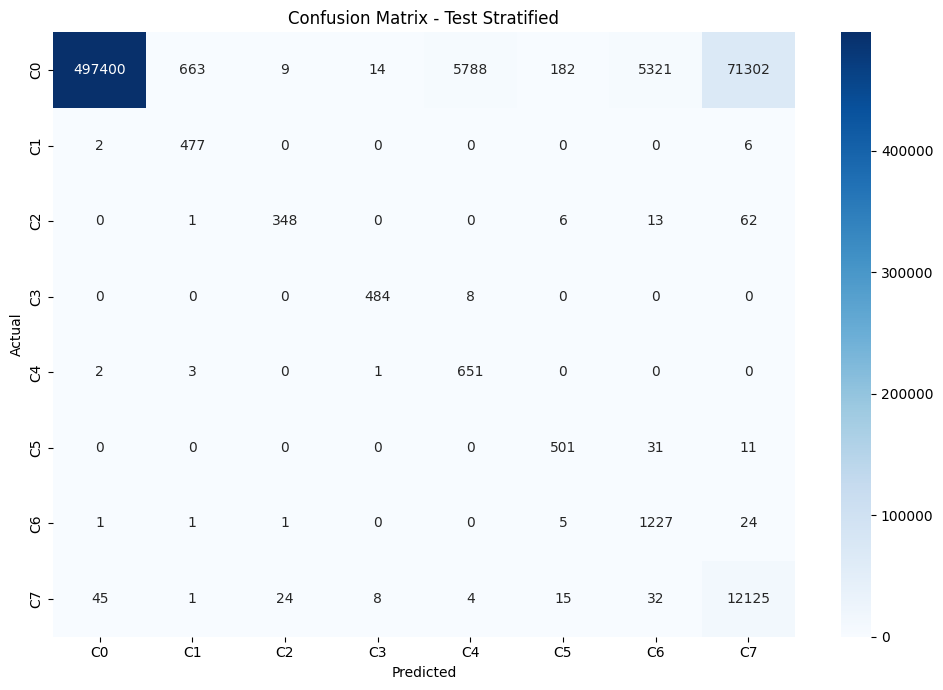

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("📊 گزارش طبقه‌بندی روی داده تست واقعی (stratified):\n")
print(classification_report(y_test_strat, y_pred_classes, target_names=[f"Class {i}" for i in range(8)]))

# رسم Confusion Matrix
cm = confusion_matrix(y_test_strat, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"C{i}" for i in range(8)],
            yticklabels=[f"C{i}" for i in range(8)])
plt.title("Confusion Matrix - Test Stratified")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ذخیره در صورت نیاز
df_results = pd.DataFrame({
    'true_label': y_test_strat,
    'predicted_label': y_pred_classes
})
df_results.to_csv("test_results_stratified_safe.csv", index=False)


In [ ]:
#آموزش مدل LSTM روی کل داده (بدون undersampling)

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder
import numpy as np

# فرض: X_sequences و y_labels از قبل وجود دارند

# انکد لیبل‌ها
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

# انتخاب 5٪ داده به‌صورت stratified
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.95, random_state=42)
for train_idx, _ in sss.split(X_sequences, y_encoded):
    X_safe = X_sequences[train_idx]
    y_safe = y_encoded[train_idx]

print("✅ داده ایمن برای آموزش:")
print("X_safe:", X_safe.shape)
print("y_safe:", y_safe.shape)


✅ داده ایمن برای آموزش:
X_safe: (149199, 30, 7)
y_safe: (149199,)


نگاشت کلاس‌ها:
0 → کلاس 0
1 → کلاس 1
2 → کلاس 2
3 → کلاس 3
4 → کلاس 4
5 → کلاس 5
6 → کلاس 6
7 → کلاس 7


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1865/1865 - 46s - 25ms/step - accuracy: 0.9791 - loss: 0.0916 - val_accuracy: 0.9844 - val_loss: 0.0585
Epoch 2/20
1865/1865 - 86s - 46ms/step - accuracy: 0.9859 - loss: 0.0531 - val_accuracy: 0.9861 - val_loss: 0.0490
Epoch 3/20
1865/1865 - 78s - 42ms/step - accuracy: 0.9868 - loss: 0.0479 - val_accuracy: 0.9877 - val_loss: 0.0464
Epoch 4/20
1865/1865 - 43s - 23ms/step - accuracy: 0.9874 - loss: 0.0444 - val_accuracy: 0.9884 - val_loss: 0.0392
Epoch 5/20
1865/1865 - 84s - 45ms/step - accuracy: 0.9874 - loss: 0.0423 - val_accuracy: 0.9888 - val_loss: 0.0392
Epoch 6/20
1865/1865 - 79s - 42ms/step - accuracy: 0.9883 - loss: 0.0391 - val_accuracy: 0.9884 - val_loss: 0.0377
Epoch 7/20
1865/1865 - 83s - 44ms/step - accuracy: 0.9886 - loss: 0.0368 - val_accuracy: 0.9887 - val_loss: 0.0357
Epoch 8/20
1865/1865 - 83s - 44ms/step - accuracy: 0.9893 - loss: 0.0354 - val_accuracy: 0.9892 - val_loss: 0.0348
Epoch 9/20
1865/1865 - 82s - 44ms/step - accuracy: 0.9894 - loss: 0.0345 - val_a

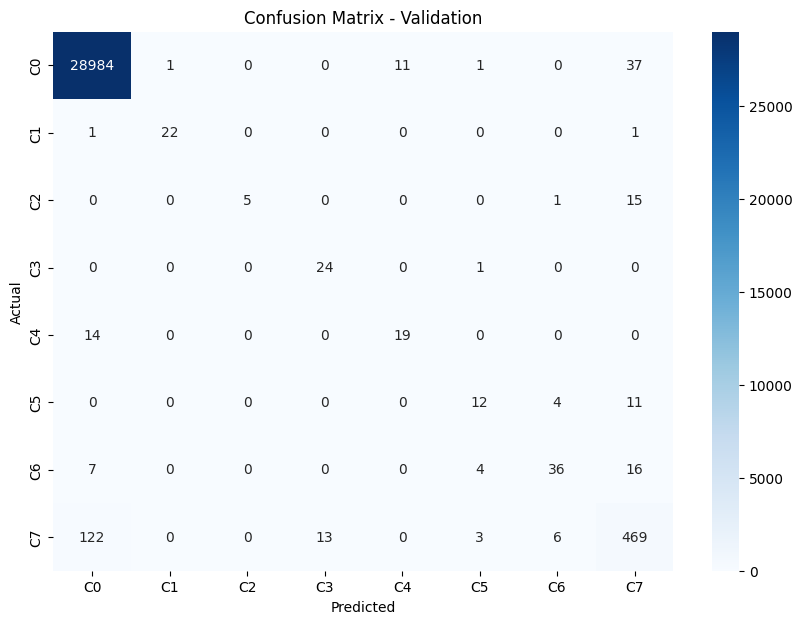

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ انکود کردن برچسب‌ها
label_encoder = LabelEncoder()
y_safe_encoded = label_encoder.fit_transform(y_safe)

# نگاشت کلاس‌ها
print("نگاشت کلاس‌ها:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"{cls} → کلاس {i}")

# 2️⃣ تقسیم Train/Validation
X_train_safe, X_val_safe, y_train_safe, y_val_safe = train_test_split(
    X_safe, y_safe_encoded,
    test_size=0.2,
    stratify=y_safe_encoded,
    random_state=42
)

# 3️⃣ تعریف مدل LSTM
model = Sequential([
    LSTM(64, input_shape=(30, 7), return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(np.unique(y_safe_encoded)), activation='softmax')  # خروجی به تعداد کلاس‌ها
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4️⃣ آموزش مدل
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_safe, y_train_safe,
    validation_data=(X_val_safe, y_val_safe),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=2
)

# 5️⃣ ارزیابی روی Validation
y_val_pred = model.predict(X_val_safe)
y_val_classes = np.argmax(y_val_pred, axis=1)

# گزارش
print("\n📊 گزارش طبقه‌بندی روی Validation:\n")
print(classification_report(y_val_safe, y_val_classes, target_names=[f"Class {i}" for i in range(len(np.unique(y_safe_encoded)))]))

# Confusion Matrix
cm = confusion_matrix(y_val_safe, y_val_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"C{i}" for i in range(cm.shape[1])],
            yticklabels=[f"C{i}" for i in range(cm.shape[0])])
plt.title("Confusion Matrix - Validation")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
#ذخیره مدل LSTM
model.save('/content/drive/MyDrive/SolarDataset/model_lstm_safe.h5')

In [ ]:
# مسیر فایل ذخیره‌شده
model = load_model('/content/drive/MyDrive/SolarDataset/model_lstm_safe.h5')

In [ ]:
from sklearn.model_selection import train_test_split

# تقسیم داده ایمن به train و test به صورت stratified
X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(
    X_safe, y_safe,
    test_size=0.2,
    stratify=y_safe,
    random_state=42
)

print("📊 توزیع کلاس‌ها در Test stratified:")
unique, counts = np.unique(y_test_strat, return_counts=True)
for u, c in zip(unique, counts):
    print(f"کلاس {u}: {c} نمونه")

print("✅ Shapes:")
print("X_test_strat:", X_test_strat.shape)
print("y_test_strat:", y_test_strat.shape)


📊 توزیع کلاس‌ها در Test stratified:
کلاس 0: 29034 نمونه
کلاس 1: 24 نمونه
کلاس 2: 21 نمونه
کلاس 3: 25 نمونه
کلاس 4: 33 نمونه
کلاس 5: 27 نمونه
کلاس 6: 63 نمونه
کلاس 7: 613 نمونه
✅ Shapes:
X_test_strat: (29840, 30, 7)
y_test_strat: (29840,)


933/933 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00     29034
     Class 1       0.96      0.92      0.94        24
     Class 2       1.00      0.24      0.38        21
     Class 3       0.65      0.96      0.77        25
     Class 4       0.63      0.58      0.60        33
     Class 5       0.57      0.44      0.50        27
     Class 6       0.77      0.57      0.65        63
     Class 7       0.85      0.77      0.81       613

    accuracy                           0.99     29840
   macro avg       0.80      0.68      0.71     29840
weighted avg       0.99      0.99      0.99     29840



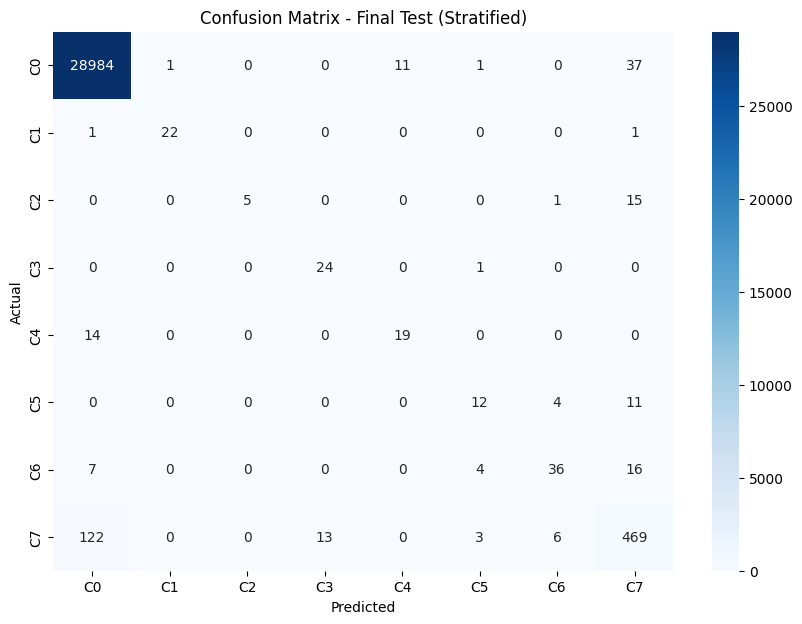

In [ ]:
# پیش‌بینی
y_pred = model.predict(X_test_strat)
y_classes = np.argmax(y_pred, axis=1)

# گزارش
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test_strat, y_classes, target_names=[f"Class {i}" for i in range(8)]))

# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_strat, y_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"C{i}" for i in range(8)],
            yticklabels=[f"C{i}" for i in range(8)])
plt.title("Confusion Matrix - Final Test (Stratified)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
from tensorflow.keras.models import load_model

# مسیر دلخواه در Google Drive یا Colab
# model.save("/content/model_lstm_safe.h5")
# print("✅ مدل با موفقیت ذخیره شد.")
#ذخیره مستقیم در Google Drive
model.save("/content/drive/MyDrive/SolarDataset/Finalmodel_lstm_safe.h5")
print("✅ مدل در Google Drive ذخیره شد.")

✅ مدل در Google Drive ذخیره شد.


In [ ]:
#تحلیل و بررسی خروجی تا به اینجا

In [ ]:
# ذخیره گزارش طبقه‌بندی (به فایل متنی)
from sklearn.metrics import classification_report

report_text = classification_report(y_test_strat, y_classes, target_names=[f"Class {i}" for i in range(8)])

# ذخیره گزارش در فایل
with open("classification_report_lstm.txt", "w") as f:
    f.write(report_text)

print("📄 گزارش ذخیره شد: classification_report_lstm.txt")

#ذخیره مستقیم در Google Drive
with open("/content/drive/MyDrive/SolarDataset/classification_report_lstm.txt", "w") as f:
   f.write(report_text)

print("📄 گزارش در Google Drive ذخیره شد.")


📄 گزارش ذخیره شد: classification_report_lstm.txt
📄 گزارش در Google Drive ذخیره شد.


In [ ]:
#ذخیره confusion matrix به‌صورت تصویر
plt.savefig("confusion_matrix_lstm_safe.png", dpi=300)
#برای Google Drive:
plt.savefig("/content/drive/MyDrive/SolarDataset/confusion_matrix_lstm_safe.png", dpi=300)


<Figure size 640x480 with 0 Axes>

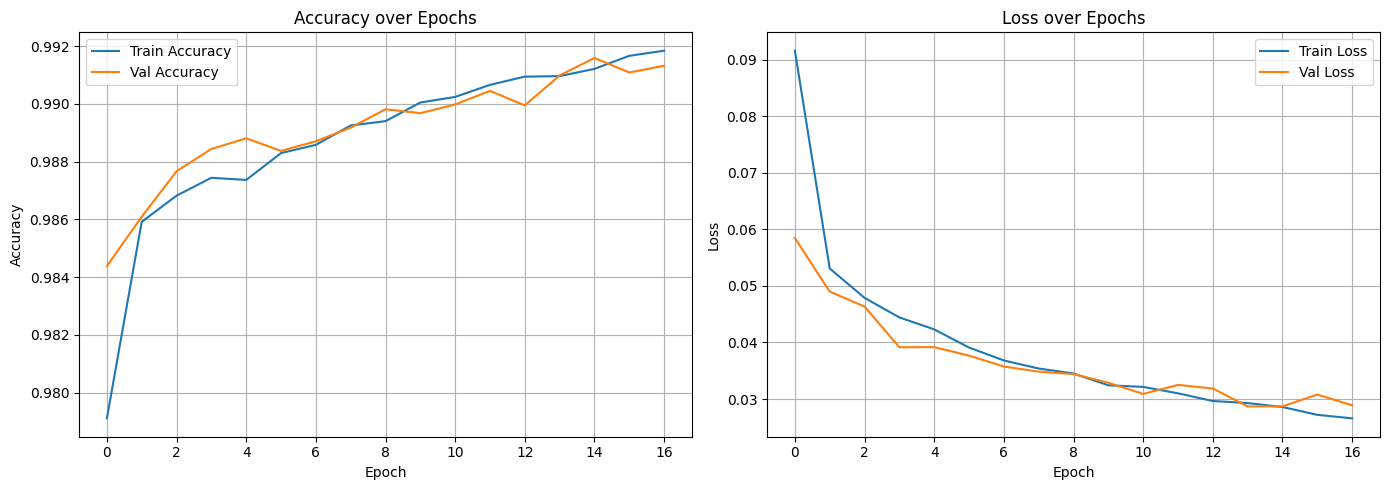

In [ ]:
import matplotlib.pyplot as plt

# دقت مدل
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# خطای مدل
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
print("y_test_strat:", type(y_test_strat), np.shape(y_test_strat))
print("y_classes:", type(y_classes), np.shape(y_classes))


y_test_strat: <class 'numpy.ndarray'> (29840,)
y_classes: <class 'numpy.ndarray'> (29840,)


In [ ]:
import pandas as pd
import numpy as np

# مقایسه موارد اشتباه
errors = y_classes != y_test_strat
error_indices = np.where(errors)[0]

# ساخت دیتافریم خطاها
error_df = pd.DataFrame({
    'Index': error_indices,
    'True Label': y_test_strat[error_indices],
    'Predicted Label': y_classes[error_indices]
})

# شمارش اشتباهات بر اساس (True, Predicted)
error_counts = error_df.groupby(['True Label', 'Predicted Label']).size().reset_index(name='Count')
error_counts = error_counts.sort_values(by='Count', ascending=False)

# نمایش
import IPython.display as display
display.display(error_counts.head(15))  # ۱۵ مورد اول خطای پرتکرار


,True Label,Predicted Label,Count
15,7,0,122
3,0,7,37
14,6,7,16
7,2,7,15
9,4,0,14
16,7,3,13
1,0,4,11
11,5,7,11
12,6,0,7
18,7,6,6


In [ ]:
# کلاس‌های واقعی و پیش‌بینی‌شده موجود هستند: y_test_strat و y_classes

# ایندکس‌هایی که کلاس واقعی 7 و پیش‌بینی‌شده هم 7 بوده (پیش‌بینی صحیح)
correct_idx = np.where((y_test_strat == 7) & (y_classes == 7))[0]

# ایندکس‌هایی که کلاس واقعی 7 ولی پیش‌بینی‌شده 0 بوده (اشتباه)
wrong_idx = np.where((y_test_strat == 7) & (y_classes == 0))[0]

print(f"✅ پیش‌بینی صحیح کلاس 7: {len(correct_idx)} نمونه")
print(f"❌ پیش‌بینی اشتباه کلاس 7 به 0: {len(wrong_idx)} نمونه")


✅ پیش‌بینی صحیح کلاس 7: 469 نمونه
❌ پیش‌بینی اشتباه کلاس 7 به 0: 122 نمونه


In [ ]:
# چند نمونه از هرکدام را برداریم
num_samples = 5

# داده‌های درست پیش‌بینی شده (واقعی 7، پیش‌بینی 7)
X_correct = X_test_strat[correct_idx[:num_samples]]

# داده‌های اشتباه پیش‌بینی شده (واقعی 7، پیش‌بینی 0)
X_wrong = X_test_strat[wrong_idx[:num_samples]]


In [ ]:
import pandas as pd

def sequences_to_df(seq_batch, label):
    return pd.DataFrame(
        seq_batch.reshape(-1, 7),
        columns=['Ia', 'Ig', 'Eg', 'Fg', 'Pg', 'Va', 'Vg']
    ).assign(Source=label)

# ساخت دو دیتافریم مجزا
df_correct = sequences_to_df(X_correct, 'Correct')
df_wrong = sequences_to_df(X_wrong, 'Wrong')

# ترکیب برای مقایسه
df_compare = pd.concat([df_correct, df_wrong], axis=0).reset_index(drop=True)


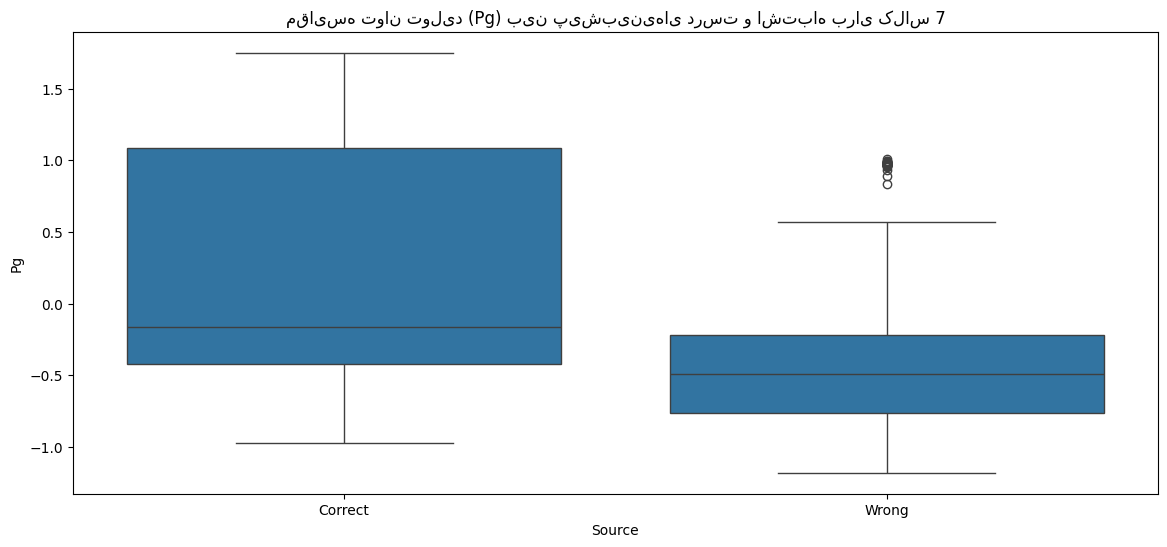

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_compare, x="Source", y="Pg")
plt.title("مقایسه توان تولید (Pg) بین پیش‌بینی‌های درست و اشتباه برای کلاس 7")
plt.show()


In [ ]:
print("✅ X_test_strat:", type(X_test_strat), X_test_strat.shape if 'X_test_strat' in globals() else "❌ Not found")
print("✅ y_test_strat:", type(y_test_strat), y_test_strat.shape if 'y_test_strat' in globals() else "❌ Not found")
print("✅ y_classes:", type(y_classes), y_classes.shape if 'y_classes' in globals() else "❌ Not found")


✅ X_test_strat: <class 'numpy.ndarray'> (29840, 30, 7)
✅ y_test_strat: <class 'numpy.ndarray'> (29840,)
✅ y_classes: <class 'numpy.ndarray'> (29840,)


✅ پیش‌بینی صحیح کلاس 7: 469 نمونه
❌ پیش‌بینی اشتباه کلاس 7 به 0: 122 نمونه


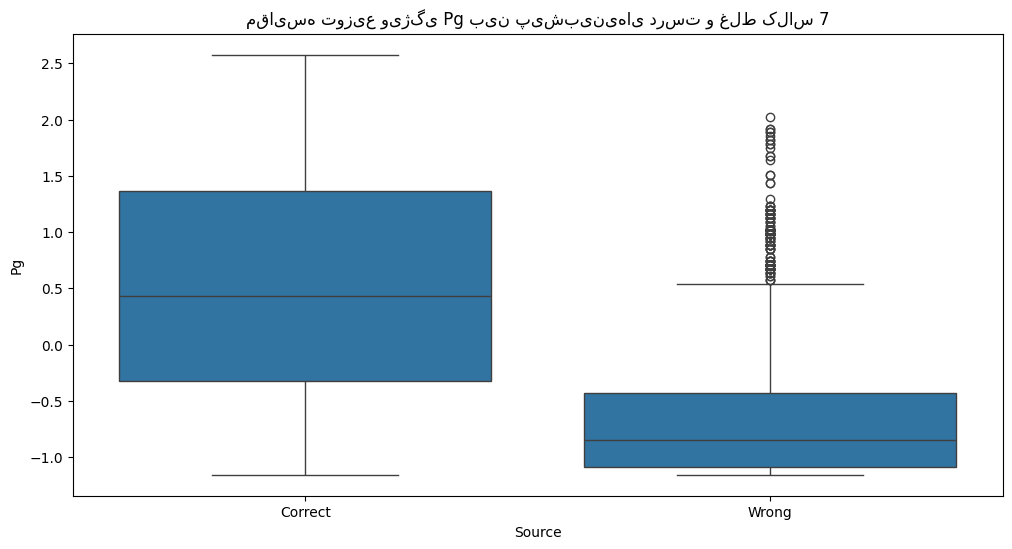

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# اندیس‌هایی از y_test_strat که کلاس واقعی‌شون 7 بوده
true_7_indices = np.where(y_test_strat == 7)[0]

# پیش‌بینی‌های این نمونه‌ها
predicted_for_7 = y_classes[true_7_indices]

# جدا کردن دو گروه
correct_indices = true_7_indices[predicted_for_7 == 7]
wrong_indices = true_7_indices[predicted_for_7 == 0]

print(f"✅ پیش‌بینی صحیح کلاس 7: {len(correct_indices)} نمونه")
print(f"❌ پیش‌بینی اشتباه کلاس 7 به 0: {len(wrong_indices)} نمونه")

# برای هر گروه میانگین ویژگی‌های ورودی در محور زمان
correct_samples = X_test_strat[correct_indices]
wrong_samples = X_test_strat[wrong_indices]

# تبدیل به DataFrame برای رسم
def prepare_dataframe(samples, label):
    reshaped = samples.reshape((samples.shape[0], -1))  # (N, 30*7)
    df = pd.DataFrame(reshaped)
    df['Source'] = label
    return df

df_correct = prepare_dataframe(correct_samples, 'Correct')
df_wrong = prepare_dataframe(wrong_samples, 'Wrong')

df_all = pd.concat([df_correct, df_wrong], ignore_index=True)

# رسم boxplot از یکی از ویژگی‌ها، مثلاً Pg که فرض می‌کنیم در index 0 از هر تایم‌استپ است
# پس ستون‌های Pg خواهند بود: 0, 7, 14, ..., 203
pg_cols = [i for i in range(0, 210, 7)]  # چون 30 تایم‌استپ × 7 ویژگی

df_pg = df_all[[col for col in pg_cols] + ['Source']]
df_pg_melted = df_pg.melt(id_vars='Source', var_name='Timestep', value_name='Pg')

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_pg_melted, x='Source', y='Pg')
plt.title("مقایسه توزیع ویژگی Pg بین پیش‌بینی‌های درست و غلط کلاس 7")
plt.show()
